<a href="https://colab.research.google.com/github/RobertsEshenvalds/test/blob/main/09_k_means_unsolved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9: Customer Segmentation with K-Means Clustering

In this lab, you will apply K-Means clustering to segment customers based on their **Annual Income** and **Spending Score**. You will:

1. Load and explore the Mall Customers dataset
2. Preprocess features using standardisation
3. Use the **Elbow Method** to find the optimal number of clusters
4. Train a K-Means model and assign cluster labels
5. Visualise and interpret the resulting customer segments
6. *(Bonus)* Evaluate clustering quality with the Silhouette Score

**Dataset:** [Mall Customer Segmentation](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) — download `Mall_Customers.csv` and upload it to your Google Drive.

## Step 0: Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## Step 1: Mount Google Drive & Load the Dataset

Upload `Mall_Customers.csv` to your Google Drive (e.g. into a folder called `datasets`), then adjust the path below to match.

In [12]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Using the file ID from your link to ensure the file is available
file_id = '1QUWp5po_Ii0_cBI5Ff6wMwLeWAjKE4PN'
destination = '/content/Mall_Customers.csv'

if not os.path.exists(destination):
    !gdown --id {file_id} -O {destination}

Mounted at /content/drive


In [13]:
DATA_PATH = '/content/Mall_Customers.csv'
df = pd.read_csv(DATA_PATH)
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Explore the Data

Display the first rows, check shape, data types, and missing values.

In [14]:
display(df.head(5))
display(df.info())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

In [15]:
print(f"Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (200, 5)

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [22]:
# Ensure df is defined and show descriptive statistics
try:
    display(df.describe())
except NameError:
    print("Error: 'df' is not defined. Please run the data loading cell (Step 1) first.")

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.400000
std,57.879185,13.969007,26.264721,25.823522,1.449311
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,1.000000
75%,150.250000,49.000000,78.000000,73.000000,3.000000
max,200.000000,70.000000,137.000000,99.000000,4.000000


## Step 2: Data Preprocessing

Select the features **Annual Income (k$)** and **Spending Score (1-100)**, then standardise them using `StandardScaler`.

In [16]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessed features (first 5 rows):")
print(X_scaled[:5])

Preprocessed features (first 5 rows):
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## Step 3: Elbow Method — Finding the Optimal *k*

Fit K-Means for *k* = 1 … 10 and record the **inertia** (within-cluster sum of squares). Plot the elbow curve.

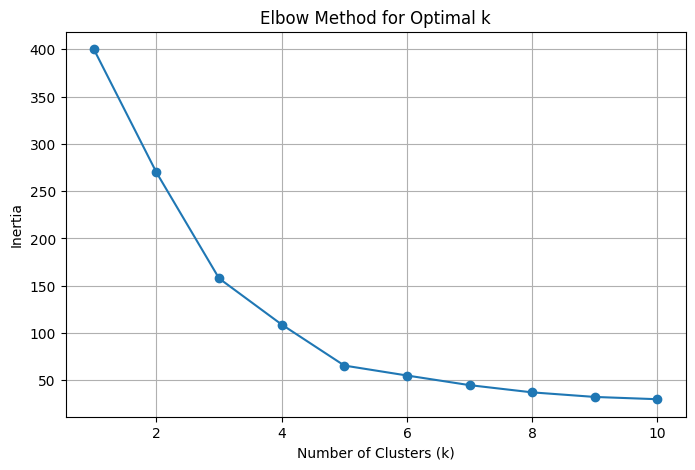

In [17]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

### *(Bonus)* Silhouette Analysis

Compute the silhouette score for *k* = 2 … 10 and plot it. The peak indicates the best separation.

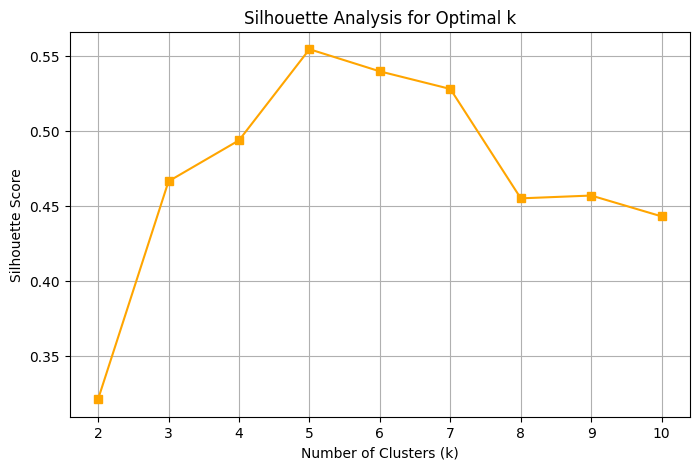

In [18]:
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='s', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.grid(True)
plt.show()

## Step 4: Train the K-Means Model

Based on the elbow curve (and optionally the silhouette plot), choose the optimal *k* and fit the model.

In [19]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Step 5: Visualise the Clusters

Create a scatter plot of **Annual Income** vs **Spending Score**, coloured by cluster. Also plot the cluster centroids.

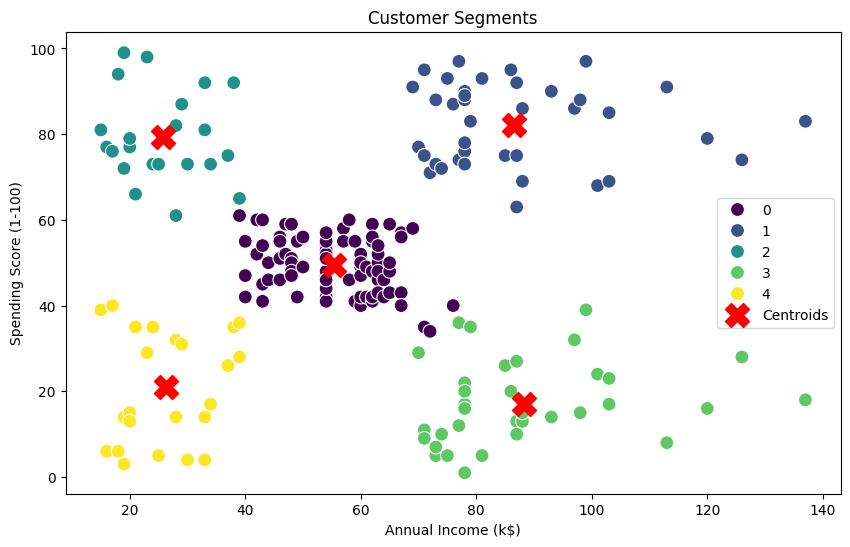

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='viridis', s=100)

centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Customer Segments')
plt.legend()
plt.show()

## Step 6: Interpret the Clusters

Compute the mean of each original feature per cluster and describe the customer segments.

In [21]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
display(cluster_summary)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


### Detailed Customer Segment Profiles

Based on the cluster means and visualization, here is a detailed description of our 5 customer segments:

1.  **Cluster 0 (Standard):** These are middle-aged customers (~43 years old) with mid-range salaries (~$55k) and mid-range spending habits. They represent the 'average' shopper.
2.  **Cluster 1 (Target/High-Spenders):** This is the most lucrative segment. They are relatively young (~32 years old) with high annual incomes (~$86k) and very high spending scores. They should be the primary focus for new product launches and loyalty programs.
3.  **Cluster 2 (Careless/Impulsive):** These are very young customers (~25 years old) with low annual income (~$25k) but high spending scores. They likely prioritize trends and immediate gratification over budget constraints.
4.  **Cluster 3 (Sensible/Conservative):** These are high-income individuals (~$88k) around 41 years old who have very low spending scores. They have the capital to spend but are highly selective or frugal; they might respond better to value-based or quality-focused marketing.
5.  **Cluster 4 (Frugal/Low-Income):** These are older customers (~45 years old) with low income and low spending. They are budget-conscious and likely only purchase essentials or items on deep discount.

### **Step 6: Interpret the Clusters**

**Your interpretation:**

*   **Cluster 0 (Standard):** Middle-aged customers (about 43 years old) with average annual income (about $55k) and average spending scores. They represent the 'average' shopper.

*   **Cluster 1 (Target):** Young adults (about 32 years old) with high annual income (about $86k) and high spending scores. This is the primary target for premium marketing and loyalty programs.

*   **Cluster 2 (Careless):** Very young adults (about 25 years old) with low annual income but high spending scores; likely impulsive or trend-driven buyers.

*   **Cluster 3 (Sensible):** High income (about $88k) but low spending scores (about 41 years old); conservative or selective spenders who may respond to quality-focused marketing.

*   **Cluster 4 (Frugal):** Older adults (about 45 years old) with both low annual income and low spending scores; budget-conscious shoppers focusing on essentials.